# AI CUP 2026 — 桌球 rally 下一拍預測 (LGBM + TabPFN + GRU ensemble)

預測每個 rally 的下一拍 `actionId`(19)、`pointId`(10) 與 `serverGetPoint`(機率)。
**評分** `Final = 0.4·F1_action(macro) + 0.4·F1_point(macro) + 0.2·AUC`。

**經完整消融確立的設計**:
- 目標保留終結拍；訓練「前綴→下一拍」；驗證 sampled 前綴；**GroupKFold by match**。
- 特徵 = base + **fold-safe transition** `P(next_action|la,lp)`、`P(next_point|la,lp)`。
- 模型 = **LightGBM ⊕ TabPFN ⊕ 小型 GRU**，**per-task OOF 3-way 權重** + prior-correction。
- **誠實 CV Overall ≈ 0.315**(fold std 0.007)。GRU 序列模型大幅提升 action(0.284→0.304)；point 仍受本質雜訊限制。
- 已驗證**無效並剔除**: 幾何/two-stage/row-col 分解、stage-transition、lag45/first/window/role、player-id(不泛化)。

In [1]:
import os, time, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (f1_score, roc_auc_score, accuracy_score, log_loss,
    brier_score_loss, average_precision_score, precision_recall_fscore_support)
import lightgbm as lgb
from tabpfn import TabPFNClassifier
from tabpfn_extensions.many_class import ManyClassClassifier
import torch, torch.nn as nn
warnings.filterwarnings("ignore")
DATA="../data"; SEED=42; np.random.seed(SEED); torch.manual_seed(SEED)
ACLS=np.arange(19); PCLS=np.arange(10); DEV="cuda"
print("ready | lgbm",lgb.__version__,"| torch",torch.__version__,"cuda",torch.cuda.is_available())

/home/ryueee17/.conda/envs/aicup2026/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ready | lgbm 4.6.0 | torch 2.5.1+cu121 cuda True


In [2]:
train=pd.read_csv(f"{DATA}/train.csv"); test=pd.read_csv(f"{DATA}/test_new.csv")
print("train",train.shape,"rallies",train.rally_uid.nunique(),"| test",test.shape,"rallies",test.rally_uid.nunique())

train (84707, 18) rallies 14995 | test (5668, 17) rallies 1845


In [3]:
# ===== 特徵 (tabular: base + fold-safe transition) =====
STROKE=["strikeId","handId","strengthId","spinId","pointId","actionId","positionId"]
REC=["scoreSelf","scoreOther"]+STROKE
def feats(strokes,sex,L):
    last=strokes[L-1]
    f={"sex":sex,"obs_len":L,"obs_parity":L%2,"next_is_server":(L+1)%2,
       "score_self":last["scoreSelf"],"score_other":last["scoreOther"],
       "score_diff":last["scoreSelf"]-last["scoreOther"],"score_sum":last["scoreSelf"]+last["scoreOther"]}
    for off in range(1,4):
        tag="last" if off==1 else f"lag{off}"
        if L>=off:
            r=strokes[L-off]
            for c in STROKE: f[f"{tag}_{c}"]=r[c]
        else:
            for c in STROKE: f[f"{tag}_{c}"]=-1
    f["mean_spin"]=float(np.mean([strokes[i]["spinId"] for i in range(L)]))
    f["mean_strength"]=float(np.mean([strokes[i]["strengthId"] for i in range(L)]))
    f["nuniq_point"]=len({strokes[i]["pointId"] for i in range(L)})
    f["nuniq_action"]=len({strokes[i]["actionId"] for i in range(L)})
    f["_la"]=last["actionId"]; f["_lp"]=last["pointId"]
    return f
def test_len_dist(t): return t.groupby("rally_uid").size().value_counts().to_dict()
def build(df,mode,tld,seed=SEED):
    rng=np.random.default_rng(seed)
    if mode=="sampled":
        Ls=np.array(sorted(tld)); Ps=np.array([tld[l] for l in Ls],float); Ps/=Ps.sum()
    rows,yA,yP,yR,g=[],[],[],[],[]
    for _,grp in df.groupby("rally_uid",sort=False):
        grp=grp.sort_values("strikeNumber"); T=len(grp)
        if T<2: continue
        sex=int(grp.sex.iloc[0]); mt=int(grp.match.iloc[0]); sgp=int(grp.serverGetPoint.iloc[0])
        st=grp[REC].to_dict("records"); na=grp.actionId.to_numpy(); npt=grp.pointId.to_numpy()
        Ll=range(1,T) if mode=="all" else ([1] if len(Ls[Ls<=T-1])==0 else [int(rng.choice(Ls[Ls<=T-1],p=(Ps[Ls<=T-1]/Ps[Ls<=T-1].sum())))])
        for L in Ll:
            rows.append(feats(st,sex,L)); yA.append(int(na[L])); yP.append(int(npt[L])); yR.append(sgp); g.append(mt)
    return pd.DataFrame(rows),np.array(yA),np.array(yP),np.array(yR),np.array(g)
def make_test(t):
    rows,u=[],[]
    for rid,grp in t.groupby("rally_uid",sort=False):
        grp=grp.sort_values("strikeNumber"); rows.append(feats(grp[REC].to_dict("records"),int(grp.sex.iloc[0]),len(grp))); u.append(int(rid))
    return pd.DataFrame(rows),np.array(u)
def fit_trans(keys,yA,yP,alpha=1.0):
    def cd(keyarr,y,nc):
        d={}
        for k,yy in zip(keyarr,y): d.setdefault(k,np.zeros(nc))[yy]+=1
        gp=np.bincount(y,minlength=nc)+alpha; gp=gp/gp.sum()
        return {k:(v+alpha)/(v.sum()+alpha*nc) for k,v in d.items()},gp
    lalp=list(zip(keys["_la"],keys["_lp"]))
    return dict(aJ=cd(lalp,yA,19),pJ=cd(lalp,yP,10))
def apply_trans(keys,T):
    out={}; lalp=list(zip(keys["_la"],keys["_lp"]))
    d,gp=T["aJ"]; M=np.array([d.get(k,gp) for k in lalp])
    for j in range(19): out[f"tA_{j}"]=M[:,j]
    d,gp=T["pJ"]; M=np.array([d.get(k,gp) for k in lalp])
    for j in range(10): out[f"tP_{j}"]=M[:,j]
    return pd.DataFrame(out)
print("tabular feature funcs ready")

tabular feature funcs ready


In [4]:
# ===== GRU (序列模型) =====
CAT=["actionId","pointId","spinId","strengthId","handId","positionId","strikeId"]
VOCAB={c:int(train[c].max())+2 for c in CAT}; VOCAB["role"]=3; VOCAB["sex"]=int(train.sex.max())+2
NCAT=len(CAT)+2; MAXLEN=30
def rally_seq(g):
    g=g.sort_values("strikeNumber")
    cat=np.stack([g[c].to_numpy()+1 for c in CAT]+[(g.strikeNumber.to_numpy()%2)+1,np.full(len(g),int(g.sex.iloc[0])+1)],axis=1)
    num=np.stack([g.scoreSelf.to_numpy()/10.,g.scoreOther.to_numpy()/10.,g.strikeNumber.to_numpy()/15.],axis=1)
    sgp=int(g.serverGetPoint.iloc[0]) if "serverGetPoint" in g.columns else 0
    mt=int(g.match.iloc[0]) if "match" in g.columns else 0
    return cat.astype(np.int64),num.astype(np.float32),g.actionId.to_numpy(),g.pointId.to_numpy(),sgp,mt
def build_seq(df,mode,tld,seed=SEED,test_mode=False):
    rng=np.random.default_rng(seed)
    if mode=="sampled":
        Ls=np.array(sorted(tld)); Ps=np.array([tld[l] for l in Ls],float); Ps/=Ps.sum()
    C=[];Nu=[];Ln=[];yA=[];yP=[];yR=[];g=[];uid=[]
    for rid,grp in df.groupby("rally_uid",sort=False):
        cat,num,na,npt,sgp,mt=rally_seq(grp); T=len(na)
        if test_mode:
            Ll=[T]  # full observed prefix
        else:
            if T<2: continue
            Ll=range(1,T) if mode=="all" else ([1] if len(Ls[Ls<=T-1])==0 else [int(rng.choice(Ls[Ls<=T-1],p=(Ps[Ls<=T-1]/Ps[Ls<=T-1].sum())))])
        for L in Ll:
            l=min(L,MAXLEN); pc=np.zeros((MAXLEN,NCAT),np.int64); pn=np.zeros((MAXLEN,3),np.float32)
            pc[:l]=cat[L-l:L]; pn[:l]=num[L-l:L]
            C.append(pc);Nu.append(pn);Ln.append(l)
            if test_mode: uid.append(int(rid))
            else: yA.append(int(na[L]));yP.append(int(npt[L]));yR.append(sgp);g.append(mt)
    if test_mode: return np.stack(C),np.stack(Nu),np.array(Ln),np.array(uid)
    return np.stack(C),np.stack(Nu),np.array(Ln),np.array(yA),np.array(yP),np.array(yR),np.array(g)
class GRUNet(nn.Module):
    def __init__(s):
        super().__init__()
        s.embs=nn.ModuleList([nn.Embedding(VOCAB[c],8,padding_idx=0) for c in CAT]+[nn.Embedding(VOCAB["role"],4,padding_idx=0),nn.Embedding(VOCAB["sex"],4,padding_idx=0)])
        s.num=nn.Linear(3,16); s.gru=nn.GRU(8*len(CAT)+4+4+16,64,batch_first=True); s.drop=nn.Dropout(0.2)
        s.ha=nn.Linear(64,19); s.hp=nn.Linear(64,10); s.hs=nn.Linear(64,1)
    def forward(s,cat,num,ln):
        e=torch.cat([s.embs[i](cat[:,:,i]) for i in range(NCAT)]+[torch.relu(s.num(num))],-1)
        pk=nn.utils.rnn.pack_padded_sequence(e,ln.cpu(),batch_first=True,enforce_sorted=False)
        _,h=s.gru(pk); h=s.drop(h[-1])
        return s.ha(h),s.hp(h),s.hs(h).squeeze(1)
def _cw(y,n):
    c=np.bincount(y,minlength=n)+1; w=1./c; return torch.tensor(w*n/w.sum(),dtype=torch.float32,device=DEV)
def gru_train(Xc,Xn,Xl,yA,yP,yR,idx,ep=12):
    m=GRUNet().to(DEV); opt=torch.optim.Adam(m.parameters(),1e-3)
    cea=nn.CrossEntropyLoss(weight=_cw(yA[idx],19)); cep=nn.CrossEntropyLoss(weight=_cw(yP[idx],10)); bce=nn.BCEWithLogitsLoss()
    Cc=torch.tensor(Xc[idx],device=DEV);Nn=torch.tensor(Xn[idx],device=DEV);Ll=torch.tensor(Xl[idx],device=DEV)
    Ta=torch.tensor(yA[idx],device=DEV);Tp=torch.tensor(yP[idx],device=DEV);Tr=torch.tensor(yR[idx].astype("float32"),device=DEV)
    ii=np.arange(len(idx))
    for e in range(ep):
        m.train(); np.random.shuffle(ii)
        for i in range(0,len(ii),256):
            b=ii[i:i+256]; opt.zero_grad()
            la,lp,lr=m(Cc[b],Nn[b],Ll[b]); (0.4*cea(la,Ta[b])+0.4*cep(lp,Tp[b])+0.2*bce(lr,Tr[b])).backward(); opt.step()
    return m
def gru_pred(m,Xc,Xn,Xl,idx):
    m.eval(); A=[];P=[];R=[]
    Cc=torch.tensor(Xc[idx],device=DEV);Nn=torch.tensor(Xn[idx],device=DEV);Ll=torch.tensor(Xl[idx],device=DEV)
    with torch.no_grad():
        for i in range(0,len(idx),512):
            la,lp,lr=m(Cc[i:i+512],Nn[i:i+512],Ll[i:i+512])
            A.append(torch.softmax(la,1).cpu().numpy());P.append(torch.softmax(lp,1).cpu().numpy());R.append(torch.sigmoid(lr).cpu().numpy())
    return np.vstack(A),np.vstack(P),np.concatenate(R)
print("GRU funcs ready")

GRU funcs ready


In [5]:
# ===== 評估 pipeline =====
def official_score(a,p,u): return 0.4*a+0.4*p+0.2*u
def clf_diag(name,y,proba,cls,verbose=True):
    cls=np.asarray(cls); pred=cls[proba.argmax(1)]
    macro=f1_score(y,pred,average="macro"); wf1=f1_score(y,pred,average="weighted"); acc=accuracy_score(y,pred)
    pr,rc,f1,sp=precision_recall_fscore_support(y,pred,labels=cls,zero_division=0)
    predc=pd.Series(pred).value_counts().reindex(cls,fill_value=0).to_numpy()
    if verbose:
        print(f"[{name}] macroF1={macro:.4f} wF1={wf1:.4f} acc={acc:.4f}")
        print(pd.DataFrame({"prec":pr.round(3),"rec":rc.round(3),"f1":f1.round(3),"support":sp,"pred":predc},index=cls).to_string())
    return dict(macro_f1=macro,per_class_f1=f1)
def bin_diag(name,y,prob,verbose=True):
    prob=np.clip(prob,1e-7,1-1e-7); auc=roc_auc_score(y,prob)
    q=np.quantile(prob,[0,.5,1])
    if verbose: print(f"[{name}] AUC={auc:.4f} logloss={log_loss(y,prob,labels=[0,1]):.4f} brier={brier_score_loss(y,prob):.4f} PR-AUC={average_precision_score(y,prob):.4f} | prob μ={prob.mean():.3f} σ={prob.std():.3f}")
    return dict(auc=auc)
def fold_report(fid,trg,vag):
    ov=set(trg)&set(vag)
    if ov: raise ValueError(f"[fold {fid}] match overlap {sorted(ov)[:3]}")
    return dict(fold=fid,train_rows=len(trg),valid_rows=len(vag),tr_matches=len(set(trg)),va_matches=len(set(vag)),overlap=0)
def log_experiment(row,path="../experiments_log.csv"):
    pd.DataFrame([{**row,"timestamp":pd.Timestamp.now().isoformat(timespec="seconds")}]).to_csv(path,mode="a",header=not os.path.exists(path),index=False)
def validate_submission(sub,uids,cols=("rally_uid","actionId","pointId","serverGetPoint")):
    for c in cols:
        if c not in sub.columns: raise ValueError(f"缺欄位 {c}")
    if len(sub)!=len(set(uids)): raise ValueError(f"row {len(sub)}!=預期 {len(set(uids))}")
    if sub.rally_uid.duplicated().any(): raise ValueError("重複 rally_uid")
    if set(uids)-set(sub.rally_uid): raise ValueError("缺 rally_uid")
    if sub[list(cols)].isnull().any().any(): raise ValueError("有 null")
    sg=sub.serverGetPoint.to_numpy()
    if (sg<0).any() or (sg>1).any(): raise ValueError("serverGetPoint 超界")
    print(f"submission 驗證通過 ✓ rows={len(sub)} action_vc={dict(sub.actionId.value_counts().head(3))} point_vc={dict(sub.pointId.value_counts().head(3))} sgp μ={sg.mean():.3f}")
def prior_of(y,cls): return np.array([(y==c).mean() for c in cls])
def align(p,c,full):
    o=np.zeros((p.shape[0],len(full))); idx={cc:i for i,cc in enumerate(c)}
    for j,cc in enumerate(full):
        if cc in idx: o[:,j]=p[:,idx[cc]]
    return o
def lgbc(bal=True): return lgb.LGBMClassifier(n_estimators=400,learning_rate=0.05,num_leaves=63,subsample=0.8,colsample_bytree=0.8,class_weight=("balanced" if bal else None),random_state=SEED,n_jobs=-1,verbose=-1)
print("eval pipeline ready")

eval pipeline ready


In [6]:
# ===== 建樣本 + fold(by match) + 檢查 =====
tld=test_len_dist(test); t=time.time()
Xa,yA,yP,yR,ga=build(train,"all",tld); Xs,eA,eP,eR,gs=build(train,"sampled",tld)
KEY=["_la","_lp"]; BASE=[c for c in Xa.columns if c not in KEY]
matches=np.array(sorted(set(ga)|set(gs))); gkf=GroupKFold(5); fo={}
for f,(_,vi) in enumerate(gkf.split(matches,groups=matches)):
    for m in matches[vi]: fo[m]=f
af=np.array([fo[m] for m in ga]); sf=np.array([fo[m] for m in gs])
prA=prior_of(yA,ACLS); prP=prior_of(yP,PCLS)
print(f"all{Xa.shape} sampled{Xs.shape} {time.time()-t:.0f}s")
for f in range(5): print(fold_report(f,ga[af!=f],gs[sf==f]))

all(69712, 35) sampled(14995, 35) 13s
{'fold': 0, 'train_rows': 57087, 'valid_rows': 2706, 'tr_matches': 172, 'va_matches': 44, 'overlap': 0}
{'fold': 1, 'train_rows': 57709, 'valid_rows': 2944, 'tr_matches': 173, 'va_matches': 43, 'overlap': 0}
{'fold': 2, 'train_rows': 54122, 'valid_rows': 3218, 'tr_matches': 173, 'va_matches': 43, 'overlap': 0}
{'fold': 3, 'train_rows': 56094, 'valid_rows': 2986, 'tr_matches': 173, 'va_matches': 43, 'overlap': 0}
{'fold': 4, 'train_rows': 53836, 'valid_rows': 3141, 'tr_matches': 173, 'va_matches': 43, 'overlap': 0}


## §1 LightGBM 學習曲線 (train/val loss + accuracy)

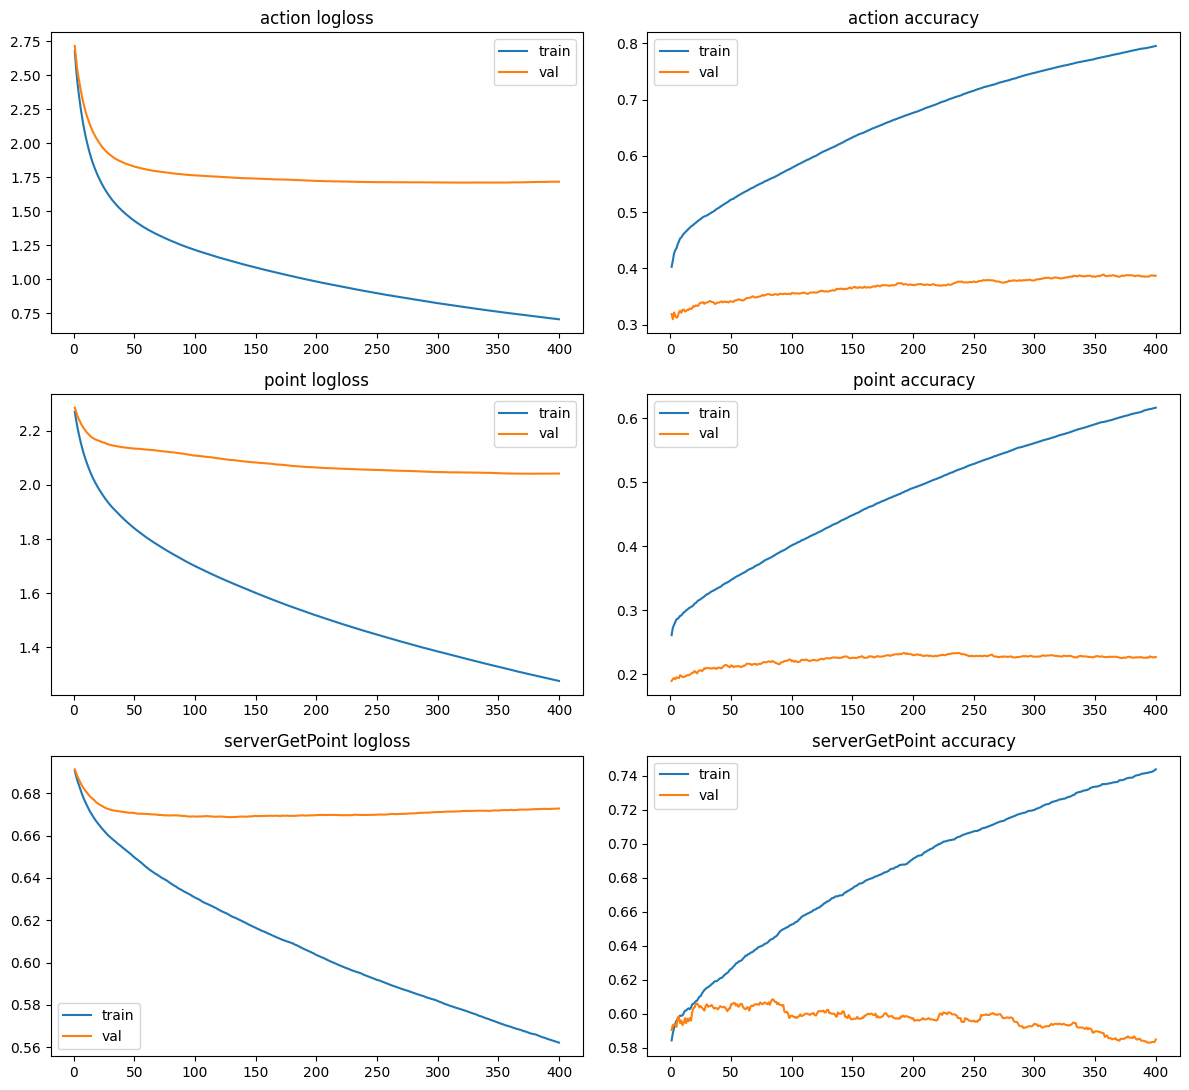

In [7]:
trm0,evm0=(af!=0),(sf==0)
def lc(ya,ye,mc):
    m=lgbc(); met=["multi_logloss","multi_error"] if mc else ["binary_logloss","binary_error"]
    m.fit(Xa.loc[trm0,BASE],ya[trm0],eval_set=[(Xa.loc[trm0,BASE],ya[trm0]),(Xs.loc[evm0,BASE],ye[evm0])],eval_names=["train","val"],eval_metric=met,callbacks=[lgb.log_evaluation(0)])
    return m.evals_result_,met
fig,ax=plt.subplots(3,2,figsize=(12,11))
for i,(nm,ya,ye,mc) in enumerate([("action",yA,eA,True),("point",yP,eP,True),("serverGetPoint",yR,eR,False)]):
    ev,met=lc(ya,ye,mc); ll,er=met; it=range(1,len(ev["train"][ll])+1)
    ax[i,0].plot(it,ev["train"][ll],label="train");ax[i,0].plot(it,ev["val"][ll],label="val");ax[i,0].set_title(f"{nm} logloss");ax[i,0].legend()
    ax[i,1].plot(it,[1-x for x in ev["train"][er]],label="train");ax[i,1].plot(it,[1-x for x in ev["val"][er]],label="val");ax[i,1].set_title(f"{nm} accuracy");ax[i,1].legend()
plt.tight_layout(); plt.show()

## §2 CV: LGBM + TabPFN + GRU → OOF 機率 (快取)

In [8]:
# 2a. LGBM + TabPFN OOF (transition fold-safe) — 快取 oof_probs.npz (TabPFN 慢)
if os.path.exists("oof_probs.npz"):
    z=np.load("oof_probs.npz"); LA,LP,LR,TA,TP,TR,YA,YP,YR,evfold=[z[k] for k in ["LA","LP","LR","TA","TP","TR","YA","YP","YR","evfold"]]
    print("loaded cached LGBM+TabPFN OOF")
else:
    LA,LP,LR,TA,TP,TR,YA,YP,YR=[[] for _ in range(9)]; evfold=[]
    for f in range(5):
        trm=af!=f; evm=sf==f; sm=sf!=f; t=time.time()
        kt={k:Xa.loc[trm,k].to_numpy() for k in KEY}; T=fit_trans(kt,yA[trm],yP[trm])
        Ft=apply_trans(kt,T); Ft.index=Xa.index[trm]
        Fe=apply_trans({k:Xs.loc[evm,k].to_numpy() for k in KEY},T); Fe.index=Xs.index[evm]
        Fs=apply_trans({k:Xs.loc[sm,k].to_numpy() for k in KEY},T); Fs.index=Xs.index[sm]
        Xt=pd.concat([Xa.loc[trm,BASE],Ft],axis=1); Xe=pd.concat([Xs.loc[evm,BASE],Fe],axis=1); XsT=pd.concat([Xs.loc[sm,BASE],Fs],axis=1)
        m=lgbc().fit(Xt,yA[trm]); LA.append(align(m.predict_proba(Xe),m.classes_,ACLS))
        m=lgbc().fit(Xt,yP[trm]); LP.append(align(m.predict_proba(Xe),m.classes_,PCLS))
        m=lgbc(False).fit(Xt,yR[trm]); LR.append(m.predict_proba(Xe)[:,1])
        bp=TabPFNClassifier(device=DEV,ignore_pretraining_limits=True).fit(XsT,eP[sm]); TP.append(align(bp.predict_proba(Xe),bp.classes_,PCLS))
        br=TabPFNClassifier(device=DEV,ignore_pretraining_limits=True).fit(XsT,eR[sm]); TR.append(br.predict_proba(Xe)[:,1])
        mc=ManyClassClassifier(estimator=TabPFNClassifier(device=DEV,ignore_pretraining_limits=True),alphabet_size=10,random_state=SEED).fit(XsT,eA[sm]); TA.append(align(mc.predict_proba(Xe),mc.classes_,ACLS))
        YA.append(eA[evm]);YP.append(eP[evm]);YR.append(eR[evm]);evfold.append(np.full((evm).sum(),f)); print(f"  fold{f} {time.time()-t:.0f}s")
    LA=np.vstack(LA);LP=np.vstack(LP);LR=np.concatenate(LR);TA=np.vstack(TA);TP=np.vstack(TP);TR=np.concatenate(TR)
    YA=np.concatenate(YA);YP=np.concatenate(YP);YR=np.concatenate(YR);evfold=np.concatenate(evfold)
    np.savez("oof_probs.npz",LA=LA,LP=LP,LR=LR,TA=TA,TP=TP,TR=TR,YA=YA,YP=YP,YR=YR,evfold=evfold)

loaded cached LGBM+TabPFN OOF


In [9]:
# 2b. GRU OOF — 快取 gru_oof.npz
if os.path.exists("gru_oof.npz"):
    zg=np.load("gru_oof.npz"); GA,GP,GR=zg["GA"],zg["GP"],zg["GR"]
    assert np.array_equal(zg["YA"],YA), "GRU OOF 對齊不符"; print("loaded cached GRU OOF")
else:
    Ca,Na,La_,gyA,gyP,gyR,gga=build_seq(train,"all",tld); Cs,Ns,Ls_,geA,geP,geR,ggs=build_seq(train,"sampled",tld)
    gaf=np.array([fo[m] for m in gga]); gsf=np.array([fo[m] for m in ggs])
    GA=[];GP=[];GR=[]
    for f in range(5):
        tri=np.where(gaf!=f)[0]; evi=np.where(gsf==f)[0]; t=time.time()
        mdl=gru_train(Ca,Na,La_,gyA,gyP,gyR,tri); a,p,r=gru_pred(mdl,Cs,Ns,Ls_,evi)
        GA.append(a);GP.append(p);GR.append(r); print(f"  GRU fold{f} {time.time()-t:.0f}s")
    GA=np.vstack(GA);GP=np.vstack(GP);GR=np.concatenate(GR)
    np.savez("gru_oof.npz",GA=GA,GP=GP,GR=GR,YA=geA if False else YA,YP=YP,YR=YR)
print("GRU OOF ready", GA.shape)

loaded cached GRU OOF
GRU OOF ready (14995, 19)


In [10]:
# 2c. 3-way per-task 權重 + β 搜尋
def beta_macro(p,y,cls,pr):
    b0=(-1.,0.)
    for b in np.linspace(0,1.5,16):
        fb=f1_score(y,cls[(p/np.clip(pr,1e-9,None)**b).argmax(1)],average="macro")
        if fb>b0[0]: b0=(fb,b)
    return b0
def search3(L,T,G,y,cls,pr):
    best=(-1,None,0)
    for wl in np.arange(0,1.01,0.1):
        for wt in np.arange(0,1.01-wl+1e-9,0.1):
            wg=round(1-wl-wt,2)
            if wg<-1e-9: continue
            f1,b=beta_macro(wl*L+wt*T+wg*G,y,cls,pr)
            if f1>best[0]: best=(f1,(round(wl,2),round(wt,2),wg),b)
    return best
def search3auc(L,T,G,y):
    best=(-1,None)
    for wl in np.arange(0,1.01,0.1):
        for wt in np.arange(0,1.01-wl+1e-9,0.1):
            wg=round(1-wl-wt,2)
            if wg<-1e-9: continue
            a=roc_auc_score(y,wl*L+wt*T+wg*G)
            if a>best[0]: best=(a,(round(wl,2),round(wt,2),wg))
    return best
fa,WA,BA=search3(LA,TA,GA,YA,ACLS,prA); fp,WP,BP=search3(LP,TP,GP,YP,PCLS,prP); au,WR=search3auc(LR,TR,GR,YR)
OV=official_score(fa,fp,au)
print(f"action F1a={fa:.4f} w(L,T,G)={WA} β={BA:.2f}")
print(f"point  F1p={fp:.4f} w(L,T,G)={WP} β={BP:.2f}")
print(f"server AUC={au:.4f} w(L,T,G)={WR}")
print(f"=> 3-way OOF Overall={OV:.4f}")
ensA=WA[0]*LA+WA[1]*TA+WA[2]*GA; ensP=WP[0]*LP+WP[1]*TP+WP[2]*GP; ensR=WR[0]*LR+WR[1]*TR+WR[2]*GR
fov=[official_score(f1_score(YA[evfold==f],ACLS[(ensA[evfold==f]/np.clip(prA,1e-9,None)**BA).argmax(1)],average="macro"),
                    f1_score(YP[evfold==f],PCLS[(ensP[evfold==f]/np.clip(prP,1e-9,None)**BP).argmax(1)],average="macro"),
                    roc_auc_score(YR[evfold==f],ensR[evfold==f])) for f in range(5)]
print(f"fold mean={np.mean(fov):.4f} std={np.std(fov):.4f}")
adjA=ensA/np.clip(prA,1e-9,None)**BA; adjP=ensP/np.clip(prP,1e-9,None)**BP
_=clf_diag("action OOF",YA,adjA,ACLS); print(); _=clf_diag("point OOF",YP,adjP,PCLS); print(); _=bin_diag("server OOF",YR,ensR)
log_experiment(dict(candidate="LGBM+TabPFN+GRU",action_f1=round(fa,4),point_f1=round(fp,4),server_auc=round(au,4),overall=round(OV,4),wA=str(WA),wP=str(WP),wR=str(WR)))

action F1a=0.3043 w(L,T,G)=(np.float64(0.4), np.float64(0.2), np.float64(0.4)) β=0.00
point  F1p=0.1762 w(L,T,G)=(np.float64(0.5), np.float64(0.3), np.float64(0.2)) β=0.00
server AUC=0.6145 w(L,T,G)=(np.float64(0.2), np.float64(0.8), np.float64(0.0))
=> 3-way OOF Overall=0.3151
fold mean=0.3200 std=0.0073
[action OOF] macroF1=0.3043 wF1=0.4381 acc=0.4356
     prec    rec     f1  support  pred
0   0.250  0.182  0.210      336   244
1   0.638  0.594  0.615     3603  3357
2   0.426  0.444  0.435      892   930
3   0.264  0.250  0.257      264   250
4   0.313  0.473  0.377     1202  1816
5   0.316  0.244  0.275      615   474
6   0.380  0.379  0.379     1272  1269
7   0.225  0.320  0.264      610   865
8   0.064  0.069  0.066      102   110
9   0.093  0.111  0.101      208   246
10  0.510  0.376  0.433     2957  2180
11  0.372  0.508  0.429     1123  1537
12  0.437  0.303  0.358      603   419
13  0.450  0.488  0.468     1167  1268
14  0.233  0.175  0.200       40    30
15  0.000  0.000  0

## §3 診斷圖

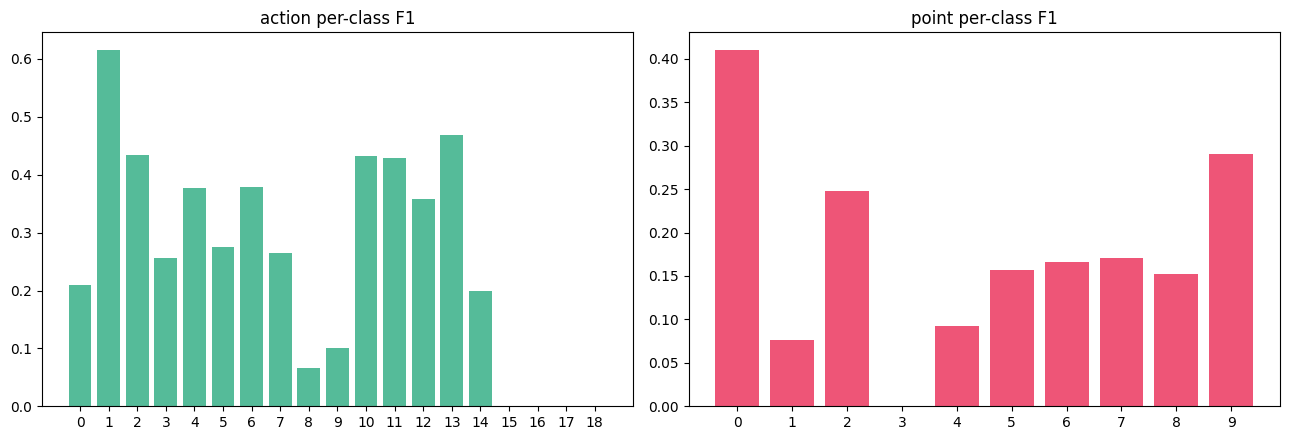

In [11]:
fig,ax=plt.subplots(1,2,figsize=(13,4.5))
af_=precision_recall_fscore_support(YA,ACLS[adjA.argmax(1)],labels=ACLS,zero_division=0)[2]
pf_=precision_recall_fscore_support(YP,PCLS[adjP.argmax(1)],labels=PCLS,zero_division=0)[2]
ax[0].bar(ACLS,af_,color="#5b9");ax[0].set_title("action per-class F1");ax[0].set_xticks(ACLS)
ax[1].bar(PCLS,pf_,color="#e57");ax[1].set_title("point per-class F1");ax[1].set_xticks(PCLS)
plt.tight_layout(); plt.show()

## §4 產生並驗證 submission (LGBM+TabPFN+GRU, 全 train 重訓)

In [12]:
Xte,uids=make_test(test); t=time.time()
Tfull=fit_trans({k:Xa[k].to_numpy() for k in KEY},yA,yP)
FA=apply_trans({k:Xa[k].to_numpy() for k in KEY},Tfull); FA.index=Xa.index
FS=apply_trans({k:Xs[k].to_numpy() for k in KEY},Tfull); FS.index=Xs.index
FT=apply_trans({k:Xte[k].to_numpy() for k in KEY},Tfull); FT.index=Xte.index
XtrA=pd.concat([Xa[BASE],FA],axis=1); XtrS=pd.concat([Xs[BASE],FS],axis=1); XteF=pd.concat([Xte[BASE],FT],axis=1)
mA=lgbc().fit(XtrA,yA); mP=lgbc().fit(XtrA,yP); mR=lgbc(False).fit(XtrA,yR)
tA=ManyClassClassifier(estimator=TabPFNClassifier(device=DEV,ignore_pretraining_limits=True),alphabet_size=10,random_state=SEED).fit(XtrS,eA)
tP=TabPFNClassifier(device=DEV,ignore_pretraining_limits=True).fit(XtrS,eP)
tR=TabPFNClassifier(device=DEV,ignore_pretraining_limits=True).fit(XtrS,eR)
Ca,Na,La_,gyA,gyP,gyR,_=build_seq(train,"all",tld); Cte,Nte,Lte,_=build_seq(test,"sampled",tld,test_mode=True)
gmdl=gru_train(Ca,Na,La_,gyA,gyP,gyR,np.arange(len(gyA)))
gA,gP,gR=gru_pred(gmdl,Cte,Nte,Lte,np.arange(len(uids)))
PA=WA[0]*align(mA.predict_proba(XteF),mA.classes_,ACLS)+WA[1]*align(tA.predict_proba(XteF),tA.classes_,ACLS)+WA[2]*gA
PP=WP[0]*align(mP.predict_proba(XteF),mP.classes_,PCLS)+WP[1]*align(tP.predict_proba(XteF),tP.classes_,PCLS)+WP[2]*gP
PR=WR[0]*mR.predict_proba(XteF)[:,1]+WR[1]*tR.predict_proba(XteF)[:,1]+WR[2]*gR
def decide(p,cls,pr,beta,mask0):
    adj=p/np.clip(pr,1e-9,None)**beta
    if mask0: adj=adj.copy(); adj[:,0]=-1e18
    return cls[adj.argmax(1)]
for tag,mask in [("incl0",False),("excl0",True)]:
    sub=pd.DataFrame({"rally_uid":uids,"actionId":decide(PA,ACLS,prA,BA,mask).astype(int),
        "pointId":decide(PP,PCLS,prP,BP,mask).astype(int),"serverGetPoint":PR}).sort_values("rally_uid")
    validate_submission(sub,uids); sub.to_csv(f"../submission_{tag}.csv",index=False)
print(f"done {time.time()-t:.0f}s")

submission 驗證通過 ✓ rows=1845 action_vc={1: np.int64(398), 13: np.int64(234), 6: np.int64(222)} point_vc={0: np.int64(651), 9: np.int64(432), 8: np.int64(164)} sgp μ=0.535
submission 驗證通過 ✓ rows=1845 action_vc={1: np.int64(400), 13: np.int64(274), 6: np.int64(223)} point_vc={9: np.int64(614), 8: np.int64(449), 7: np.int64(291)} sgp μ=0.535
done 103s
